In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# red wine 품질 등급 예측
```
1. 데이터 셋 확보 & 전처리
    결측치 처리->독립(입력)변수와 종속(타겟)변수를 분리-> 독립변수의 스케일 조정(StandardScaler)
    -> 종속변수의 균형을 확인
    -> 종속변수 원핫인코딩(pd.get_dummies)->훈련셋과 테스트셋분리(train_test_split)
2. 모델구성
3. 모델학습과정 설정(다중분류)
4. 모델학습(callbacks,comput_class_weight를 이용)
5. 모델평가(시각화, 평가, 교차표 - 테스트셋)
6. 모델저장/예측
```

## 1.데이터셋 확보및처리

In [32]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model,load_model
from tensorflow.keras.layers import Input,Dense,LeakyReLU,Dropout
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras import metrics
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,Callback, ReduceLROnPlateau
from matplotlib import pyplot as plt

In [33]:
redwine = pd.read_csv('data/winequality-red.csv',sep=';')
redwine.info()
# redwine = np.Loadtxt('data/winequality-red.csv',delimiter=';',skipprows=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [34]:
# 독립(입력)변수와 종속(타겟)변수를 분리
X_redwine = redwine.iloc[:,:-1].to_numpy()# values와 유사.numpy로 변경
y_redwine = redwine.iloc[:,-1]
X_redwine.shape, y_redwine.shape

((1599, 11), (1599,))

In [35]:
# 독립변수의 스캐일 조정
scaler = StandardScaler()
# scaler.fit(X_redwine)
# scaler_X_redwine = scaler.transform(X_redwine)
scaler_X_redwine = scaler.fit_transform(X_redwine)

In [36]:
# 종속변수의 원핫인코디;ㅇ
Y_redwine = pd.get_dummies(y_redwine)#.values
np.c_[y_redwine[2:4],Y_redwine[2:4]]

array([[5, 0, 0, 1, 0, 0, 0],
       [6, 0, 0, 0, 1, 0, 0]], dtype=int64)

In [37]:
# 종속변수의 균형을 확인
y_redwine.value_counts(normalize=True)

5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: quality, dtype: float64

In [38]:
# 독립변수와 타겟변수
scaler_X_redwine.shape,Y_redwine.shape

((1599, 11), (1599, 6))

In [39]:
# 훈련셋과 테스트셋 분리
X_train, X_test, Y_train, Y_test = train_test_split(scaler_X_redwine,
                                                   Y_redwine,
                                                   test_size=0.3,
                                                   #train_size=0.7,
                                                   stratify=Y_redwine,
                                                   random_state=12)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1119, 11), (480, 11), (1119, 6), (480, 6))

# 2. 모델구성
- 입력 11-> 64-> 50-> 30-> ->출력6
- He초기화 : 층이 깊을떄 활성화 함수를 relu사용시

In [40]:
model = Sequential(name='sequential')
model.add(Input(11))
model.add(Dense(units=64, activation='relu',kernel_initializer=HeNormal(seed=42)))
model.add(Dense(units=50, activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu',kernel_initializer='he_normal'))
model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                768       
                                                                 
 dense_9 (Dense)             (None, 50)                3250      
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense_10 (Dense)            (None, 30)                1530      
                                                                 
 dense_11 (Dense)            (None, 6)                 186       
                                                                 
Total params: 5,734
Trainable params: 5,734
Non-trainable params: 0
_________________________________________________________________


# 3.학습과정 설정

In [41]:
model.compile(loss='categorical_crossentropy', #sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy',
                      metrics.Recall(name='recall'),
                      metrics.Precision(name='precision')])

# 4. 학습시키기
- callbacks 이용

In [42]:
%%time
earlyStopping = EarlyStopping(monitor='val_loss', patience=50)
hist = model.fit(X_train,Y_train,
                validation_split=0.2, # 학습셋의 20%를 검증셋으로
                #class_weight=class_weight_dict
                callbacks=[earlyStopping],
                epochs=200, 
                verbose=2 
                )

Epoch 1/200
28/28 - 1s - loss: 1.5404 - accuracy: 0.3810 - recall: 0.0939 - precision: 0.4615 - val_loss: 1.3861 - val_accuracy: 0.4955 - val_recall: 0.2679 - val_precision: 0.5769 - 1s/epoch - 47ms/step
Epoch 2/200
28/28 - 0s - loss: 1.1477 - accuracy: 0.5475 - recall: 0.3520 - precision: 0.6128 - val_loss: 1.3091 - val_accuracy: 0.4821 - val_recall: 0.3750 - val_precision: 0.6043 - 126ms/epoch - 5ms/step
Epoch 3/200
28/28 - 0s - loss: 1.0583 - accuracy: 0.5777 - recall: 0.4056 - precision: 0.6402 - val_loss: 1.2031 - val_accuracy: 0.5089 - val_recall: 0.3661 - val_precision: 0.6029 - 124ms/epoch - 4ms/step
Epoch 4/200
28/28 - 0s - loss: 1.0112 - accuracy: 0.5911 - recall: 0.4056 - precision: 0.6448 - val_loss: 1.1483 - val_accuracy: 0.5223 - val_recall: 0.3795 - val_precision: 0.6159 - 113ms/epoch - 4ms/step
Epoch 5/200
28/28 - 0s - loss: 0.9694 - accuracy: 0.6034 - recall: 0.4358 - precision: 0.6468 - val_loss: 1.1235 - val_accuracy: 0.5312 - val_recall: 0.3973 - val_precision: 0.60

Epoch 41/200
28/28 - 0s - loss: 0.6359 - accuracy: 0.7430 - recall: 0.6872 - precision: 0.7755 - val_loss: 1.0491 - val_accuracy: 0.5714 - val_recall: 0.5491 - val_precision: 0.6119 - 125ms/epoch - 4ms/step
Epoch 42/200
28/28 - 0s - loss: 0.6130 - accuracy: 0.7553 - recall: 0.7061 - precision: 0.7698 - val_loss: 1.0698 - val_accuracy: 0.5670 - val_recall: 0.5312 - val_precision: 0.6103 - 103ms/epoch - 4ms/step
Epoch 43/200
28/28 - 0s - loss: 0.6144 - accuracy: 0.7464 - recall: 0.7106 - precision: 0.7766 - val_loss: 1.0711 - val_accuracy: 0.5536 - val_recall: 0.5045 - val_precision: 0.5885 - 109ms/epoch - 4ms/step
Epoch 44/200
28/28 - 0s - loss: 0.6287 - accuracy: 0.7441 - recall: 0.6983 - precision: 0.7726 - val_loss: 1.0503 - val_accuracy: 0.5714 - val_recall: 0.5312 - val_precision: 0.6103 - 91ms/epoch - 3ms/step
Epoch 45/200
28/28 - 0s - loss: 0.5752 - accuracy: 0.7743 - recall: 0.7263 - precision: 0.8035 - val_loss: 1.0798 - val_accuracy: 0.5804 - val_recall: 0.5312 - val_precision

In [43]:
X_train.shape

(1119, 11)

# 5. 모델평가

In [44]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

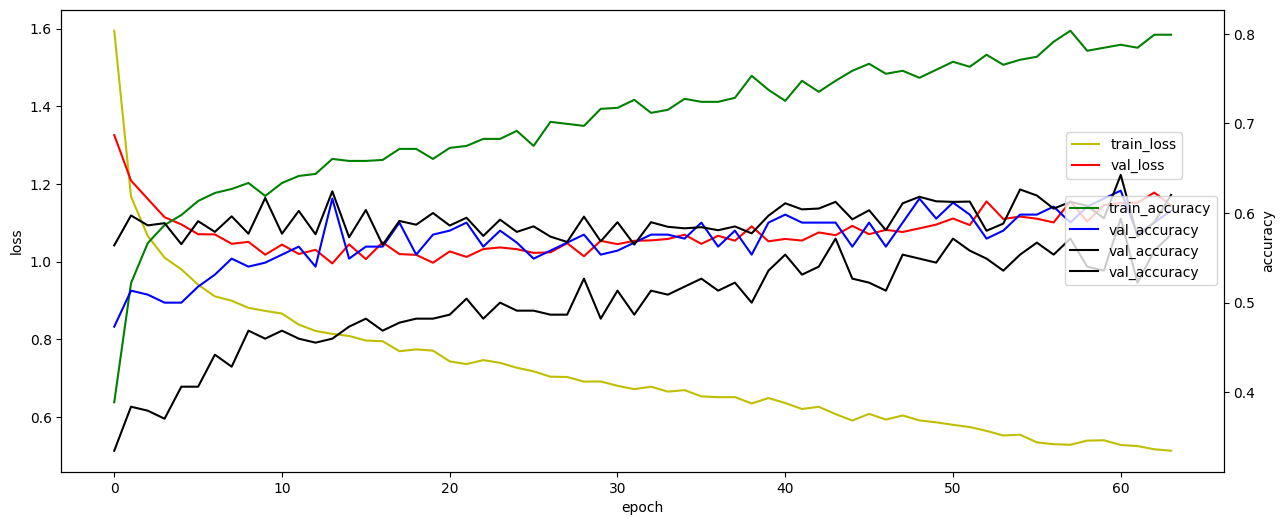

In [29]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_accuracy')
acc_ax.plot(hist.history['val_precision'], 'k', label='val_accuracy')
#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')


acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [45]:
# 평가
loss, acc, recall, precision = model.evaluate(X_test, Y_test, verbose=0)
print('정확도 :', acc)
print('재현율 :', recall)
print('정밀도 :', precision)

정확도 : 0.6354166865348816
재현율 : 0.5979166626930237
정밀도 : 0.6507936716079712


In [47]:
# 교차표를 위한 y_hat
y_hat = model.predict(X_test).argmax(axis=1) + 3 # 예측값
y = Y_test.values.argmax(axis=1) + 3 # 실제값
pd.crosstab(y, y_hat, rownames=['실제'], colnames=['예측'])

15/15 [==============================] - 0s 2ms/step


예측,3,5,6,7,8
실제,,,,,
3,0,3,0,0,0
4,1,9,5,1,0
5,0,153,45,6,0
6,1,54,120,16,1
7,0,3,23,32,2
8,0,0,2,3,0


# 6. 모델사용

In [48]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [49]:
data = [[ 7.4,0.7, 0.,  1.9,  0.076, 11., 34. , 0.9978,  3.51  ,  0.56  ,  9.4   ]]
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1)+3

1/1 [==============================] - 0s 101ms/step


array([5], dtype=int64)